In [1]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import json
import os
from tqdm import tqdm

In [43]:
TEST_DIR = "PlantDoc-Dataset/test/"
CLASSMAP_PATH = "classmap.json"
BASELINE_CKPT = "runs/frontiers2023/run2/mobilenetv3small_best.pt"
MIXED_CKPT = "runs/mixed_pv_pd/run2/mixed_model_best.pt"
IMG_SIZE = 224
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
def load_classmap(path):
    with open(path, "r") as f:
        return json.load(f)

def build_transform(normalize=False):
    t = [transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()]
    if normalize:
        t.append(transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]))
    return transforms.Compose(t)

def load_model_safely(ckpt_path):
    """Loads model and returns (model, class_names_list)"""
    ckpt = torch.load(ckpt_path, map_location="cpu")
    
    state_dict = ckpt["model"]
    w = state_dict.get("classifier.3.weight")
    if w is None:
        w = state_dict.get("classifier.1.weight")
    
    if w is None:
        raise ValueError(f"Could not find classifier weights in {ckpt_path}")
        
    num_classes = int(w.shape[0])
    print(f"Loaded checkpoint with {num_classes} classes.")
    
    # Build Model Structure
    m = models.mobilenet_v3_small(weights=None)
    m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
    m.load_state_dict(state_dict)
    m.to(DEVICE).eval()
    
    # Return the class names stored in the checkpoint (if any)
    trained_classes = ckpt.get("classes", None)
    return m, trained_classes

In [ ]:
tf = build_transform(normalize=True) 
ds_test = datasets.ImageFolder(TEST_DIR, transform=tf)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Ground Truth: The folder names in the Test Set
test_class_names = ds_test.classes
print(f"Test Set has {len(test_class_names)} classes.")

# Load Maps
cm = load_classmap(CLASSMAP_PATH)
pv_to_unified = cm["plantvillage_to_unified"]
pd_to_unified = cm["plantdoc_to_unified"]

Test Set has 27 classes.


In [30]:
model_base, base_classes = load_model_safely(BASELINE_CKPT)
    
if not base_classes or len(base_classes) != 38:
    base_classes = [str(i) for i in range(38)] # Dummy list if missing

correct_base = 0
total = 0

with torch.no_grad():
    for x, y in tqdm(dl_test, desc="Baseline"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        preds = model_base(x).argmax(1).cpu().numpy()
        
        for i, p_idx in enumerate(preds):
            gt_idx = y[i].item()
            
            try:
                pred_name_pv = base_classes[p_idx] # Model's label
                gt_name_pd   = test_class_names[gt_idx] # Test Set's label
                
                pred_u = pv_to_unified.get(pred_name_pv, "unknown_pred")
                gt_u   = pd_to_unified.get(gt_name_pd, "unknown_gt")
                
                if pred_u == gt_u:
                    correct_base += 1
                total += 1
            except IndexError:
                pass 

acc_base = 100.0 * correct_base / total if total > 0 else 0
print(f"Baseline Accuracy (Mapped): {acc_base:.2f}%")

Loaded checkpoint with 38 classes.


Baseline: 100%|██████████| 8/8 [00:30<00:00,  3.77s/it]

Baseline Accuracy (Mapped): 2.54%


In [46]:
model_ft, ft_train_classes = load_model_safely(MIXED_CKPT)
    
correct_ft = 0
total_ft = 0

with torch.no_grad():
    for x, y in tqdm(dl_test, desc="Mixed eval"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        preds = model_ft(x).argmax(1).cpu().numpy()
        
        for i, p_idx in enumerate(preds):
            gt_idx = y[i].item()
            
            pred_name = ft_train_classes[p_idx]
            gt_name = test_class_names[gt_idx]
            gt_unified = pd_to_unified.get(gt_name, "unknown_class")
            if pred_name == gt_unified:
                correct_ft += 1
            total_ft += 1

acc_ft = 100.0 * correct_ft / total_ft if total_ft > 0 else 0
print(f"Mixed Accuracy: {acc_ft:.2f}%")

Loaded checkpoint with 28 classes.


Mixed eval: 100%|██████████| 8/8 [00:26<00:00,  3.36s/it]

Mixed Accuracy: 56.78%


In [47]:
print(f"Baseline (Zero-Shot): {acc_base:.2f}%")
print(f"Fine-Tuned (Native):  {acc_ft:.2f}%")
print(f"Improvement:          +{acc_ft - acc_base:.2f}%")

Baseline (Zero-Shot): 2.54%
Fine-Tuned (Native):  56.78%
Improvement:          +54.24%


run1 confusion metrix

Gathering Predictions: 100%|██████████| 8/8 [00:29<00:00,  3.63s/it]


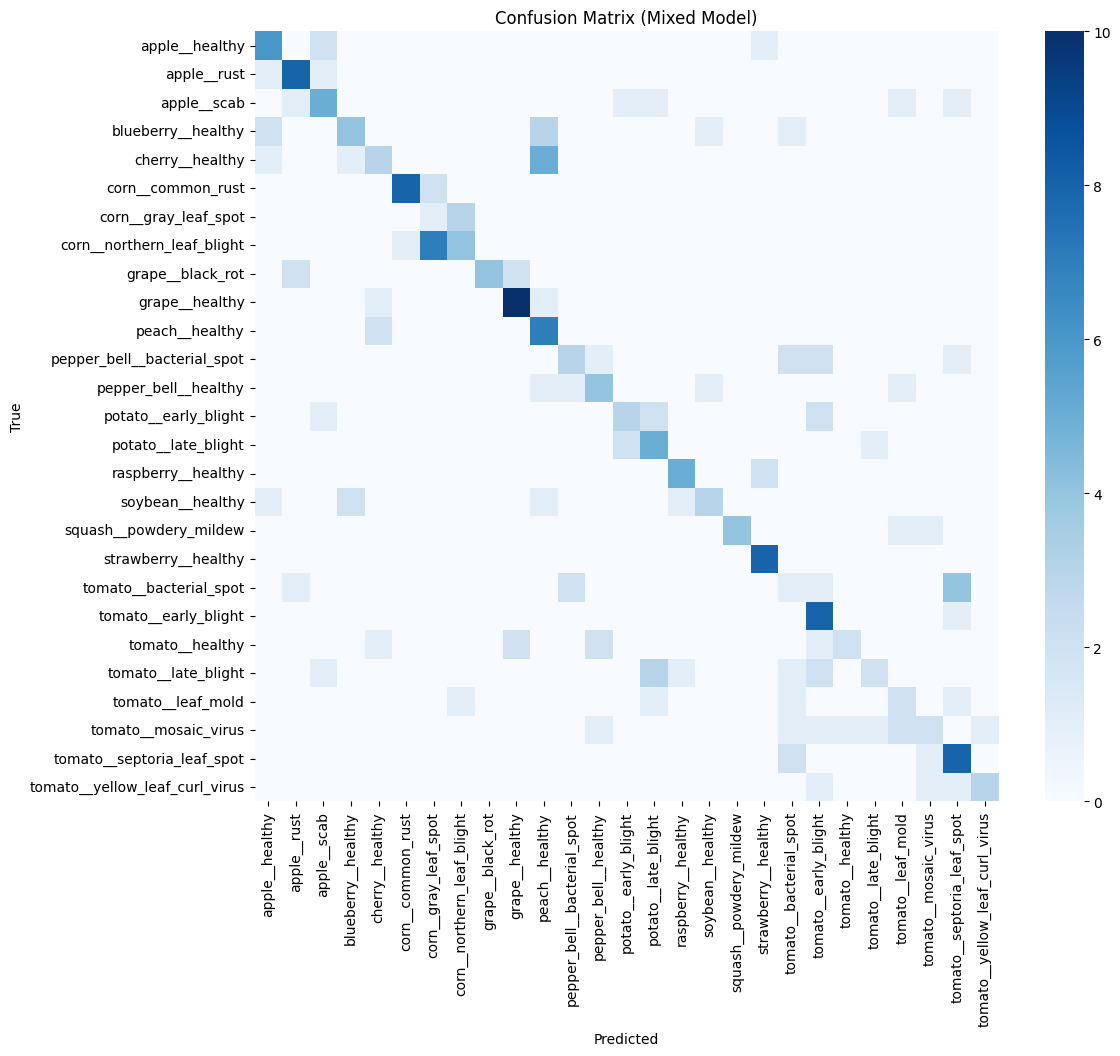

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix_mixed(model, loader, device):
    model.eval()
    all_preds = []
    all_gts = []
    
    # We need the class names to make the plot readable
    # Assuming 'ft_train_classes' are the names the model outputs
    # And we map GT to these names
    
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Gathering Predictions"):
            x = x.to(device)
            preds = model(x).argmax(1).cpu().numpy()
            
            for i, p_idx in enumerate(preds):
                # Model Prediction Name
                pred_name = ft_train_classes[p_idx]
                
                # GT Name (Mapped)
                gt_idx = y[i].item()
                gt_folder = test_class_names[gt_idx]
                gt_name = pd_to_unified.get(gt_folder, "unknown")
                
                # Only add if valid
                if gt_name in ft_train_classes:
                    all_preds.append(pred_name)
                    all_gts.append(gt_name)

    # Get unique labels for plotting
    labels = sorted(list(set(all_gts)))
    
    cm = confusion_matrix(all_gts, all_preds, labels=labels)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (Mixed Model)")
    plt.xticks(rotation=90)
    plt.show()

# Run it
plot_confusion_matrix_mixed(model_ft, dl_test, DEVICE)